# Helene's Impact on the Vulnerable West Coast of Florida 

```{image} ../thumbnails/thumbnail.png
:alt: Project Pythia logo
:width: 200px
```

---

## Overview

This notebook investigates the landfall and storm-surge impacts of Hurricane Helene (2024) along Florida’s Gulf Coast and Panhandle.  
We integrate geographic data, ERA5 fields, and surge observations to assess how Helene’s coastal impacts unfolded.

1. Review Helene’s landfall timeline and wind field structure  
2. Overlay storm surge observations with coastal topography and land use  
3. Map inundation prone regions and identify spatial vulnerability patterns  
4. Discuss Florida’s surge exposure in the context of sea level rise  
5. Conclude with implications for future hazard preparedness

---

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Geopandas](https://foundations.projectpythia.org/core/geopandas/geopandas) | Necessary | For handling shapefiles and mapping Florida’s coastal features |
| [Matplotlib basics](https://foundations.projectpythia.org/core/matplotlib/matplotlib) | Helpful | For visualizing storm surge and spatial overlays |
| [Raster and GeoTIFF data](https://foundations.projectpythia.org/core/rioxarray/rioxarray) | Helpful | Used for working with coastal elevation or inundation maps |
| Understanding of storm surge processes | Helpful | Links meteorological forcing to observed flooding impacts |

- **Time to learn:** ~20 minutes  
- **System requirements:** Access to storm surge or elevation data files (GeoTIFF or NetCDF format, <1 GB)


---

## Imports

In [1]:
#import packages
import cdsapi
import pandas as pd
import urllib.request
import xarray as xr
import numpy as np

#plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import rioxarray
import rasterio
from rasterio.plot import show

### Let's once again visualize just how large Helene's windfield is again, as the size of the wind field along with coastal bathymetry and coastline shapes can all play a role in the impacts felt by storm surge. The Western Florida Coast is one of the most vulnerable regions in the entire United States to storm surge. A long and shallow expanse of ocean waters easily allows waves and surge to build up and push inland. This effect is enhanced by concave coastlines and bays, which consists of the Tampa Bay region and Apalachee Bay. Additionally, the way Helene's eye paralled Florida accelerated the coastal storm surge threat as it moved northward past the latitude of Tampa and Apalachee Bay due to its cyclonic circulation. A paper on IKE or Integrated Kinetic Energy one of my old FSU professor's researched would be very relevant to apply to Helene's storm surge impacts. It had a lot of kinetic energy and momentum built up in the waters from the swath of its large windfield, and the water was easily pushed ashore the flat expanse of the state. 

### ChatGPT helped me with the below cell, and I commented throughout to understand the process better 

### Let's load in the three days before Helene's landfall as it approaches Florida and as the storm surge threat ramps up: September 25th, 26th, and 27th, keeping in mind that the 27th displays the worst of the storm surge and wind fields impacting the Florida coastline 

## First Section: Helene's 10m Windfield 

In [2]:
c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': ['10m_u_component_of_wind', '10m_v_component_of_wind'],
        'year': '2024',
        'month': '09',
        'day': ['25', '26', '27'], #same process as before just changing the day to a list of days for context
        'time': '00:00',
        'area': [40, -95, 10, -70], 
        'format': 'netcdf',
    },
    'era5_helene_2024.nc'
)

2025-11-11 03:47:49,723 INFO Request ID is d762b9fb-3b09-4687-ba64-8bc931413219
2025-11-11 03:47:49,850 INFO status has been updated to accepted
2025-11-11 03:48:11,383 INFO status has been updated to successful


edd30d79268ba88f7b34f1532b8eb209.nc:   0%|          | 0.00/198k [00:00<?, ?B/s]

'era5_helene_2024.nc'

✅ Loaded 25 best-track points for Hurricane Helene (2024)
📍 Using ERA5 field at 2024-09-27T00:00:00.000000 near (28.70, -84.30)
ERA5 longitude range: -95.0 to -70.0


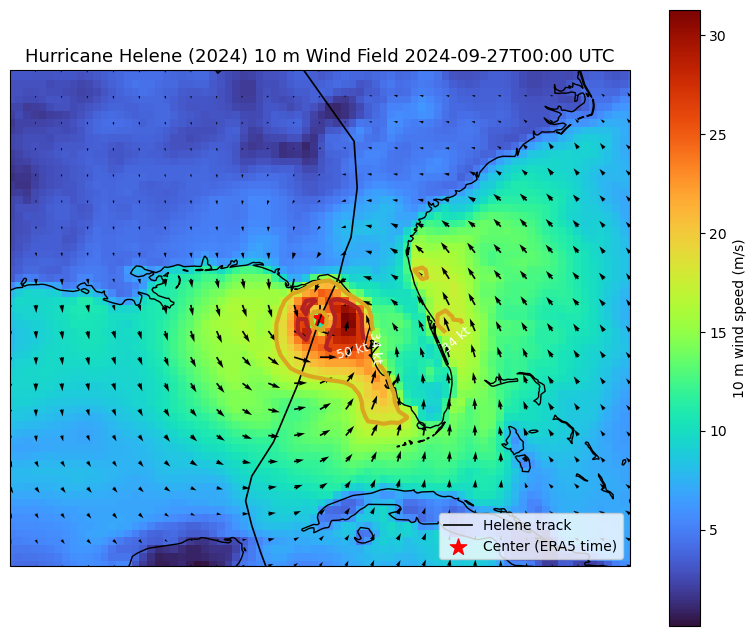

In [3]:
#Helene best track from HURDAT (1851–2024)
url = "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2024-040425.txt"

#open HURDAT2 and decode lines
with urllib.request.urlopen(url) as f:
    lines = [line.decode("utf-8").strip() for line in f.readlines()]

#isolate Helene (AL092024)
storm_lines, capture = [], False
for l in lines:
    if l.startswith("AL092024"):
        capture = True
        storm_lines.append(l)
        continue
    if capture:
        if l.startswith("AL") and not l.startswith("AL092024"):
            break
        storm_lines.append(l)

if not storm_lines:
    raise ValueError("Could not find Helene (AL092024) in HURDAT2")

#parse storm records into DataFrame
records = []
for l in storm_lines[1:]:
    parts = [p.strip() for p in l.split(",")]
    date = pd.to_datetime(parts[0] + parts[1], format="%Y%m%d%H%M")
    lat = float(parts[4][:-1]) * (1 if parts[4][-1] == "N" else -1)
    lon = float(parts[5][:-1]) * (-1 if parts[5][-1] == "W" else 1)
    wind = int(parts[6])
    records.append((date, lat, lon, wind))

helene = pd.DataFrame(records, columns=["time", "lat", "lon", "wind"])
print(f"✅ Loaded {len(helene)} best-track points for Hurricane Helene (2024)")

#match with ERA5
target_dt = pd.Timestamp("2024-09-27T00:00:00")

#find record closest to ERA5 time
helene["dt_diff"] = (helene["time"] - target_dt).abs()
row = helene.loc[helene["dt_diff"].idxmin()]
storm_time = np.datetime64(row["time"])
storm_lat, storm_lon = row["lat"], row["lon"]

print(f"📍 Using ERA5 field at {storm_time} near ({storm_lat:.2f}, {storm_lon:.2f})")

#Load ERA5 10 m wind data
ds = xr.open_dataset("era5_helene_2024.nc")

#check coordinate range (0–360 or −180–180)
lon_min, lon_max = ds.longitude.min().item(), ds.longitude.max().item()
print(f"ERA5 longitude range: {lon_min} to {lon_max}")

#select nearest valid time
ds_time = ds.sel(valid_time=storm_time, method="nearest")

#spatial subset
ds_sub = ds_time.sel(
    latitude=slice(storm_lat + 10, storm_lat - 10),
    longitude=slice(storm_lon - 15, storm_lon + 15)
)

u, v = ds_sub["u10"], ds_sub["v10"]
ws = np.sqrt(u**2 + v**2)

#convert to knots for NHC equivalence
ws_knots = ws * 1.94384
levels = [34, 50, 64]

#only shift longitude if ERA5 grid uses 0–360 format
if lon_max > 180 and storm_lon < 0:
    storm_lon = 360 + storm_lon

storm_lon = float(storm_lon)
storm_lat = float(storm_lat)

#plot wind field and track
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([storm_lon - 10, storm_lon + 10, storm_lat - 8, storm_lat + 8])
ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
ax.add_feature(cfeature.LAND, facecolor="lightgray")

#10m wind plot
ws.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="turbo", cbar_kwargs={"label": "10 m wind speed (m/s)"})

#wind barbs
ax.quiver(ws.longitude[::6], ws.latitude[::6], u[::6, ::6], v[::6, ::6],
          transform=ccrs.PlateCarree(), scale=700, regrid_shape=20)

#HURDAT track overlay
ax.plot(helene["lon"], helene["lat"], color="black", lw=1.2,
        transform=ccrs.PlateCarree(), label="Helene track")

#storm center tracker
ax.scatter(storm_lon, storm_lat, color="red", marker="*", s=150,
           transform=ccrs.PlateCarree(), label="Center (ERA5 time)")

#NHC wind thresholds
cs = ax.contour(ws_knots.longitude, ws_knots.latitude, ws_knots, levels=levels, colors=["goldenrod", "firebrick", "firebrick"],
    linewidths=[3, 3, 3], transform=ccrs.PlateCarree())
ax.clabel(cs, fmt="%d kt", inline=True, fontsize=9, colors="white")

ax.set_title(f"Hurricane Helene (2024) 10 m Wind Field {str(storm_time)[:16]} UTC", fontsize=13)
ax.legend(loc="lower right")
plt.show()

## Subsection: Helene's 10m Windfield Over 3 Days Preceeding Landfall

In [4]:
ds = xr.open_dataset("era5_helene_2024.nc")
if "valid_time" in ds.coords:
    ds = ds.rename({"valid_time": "time"}) #open dataset and change tine to valid time; it is a common error

u, v = ds["u10"], ds["v10"]
ws = np.sqrt(u**2 + v**2) * 1.94384   #compute winds in knots
print(ds.time.values)

['2024-09-25T00:00:00.000000000' '2024-09-26T00:00:00.000000000'
 '2024-09-27T00:00:00.000000000']


### I wanted to make a 3 panel plot for the windspeeds from 25th-27th to watch the windfield impact with Florida 

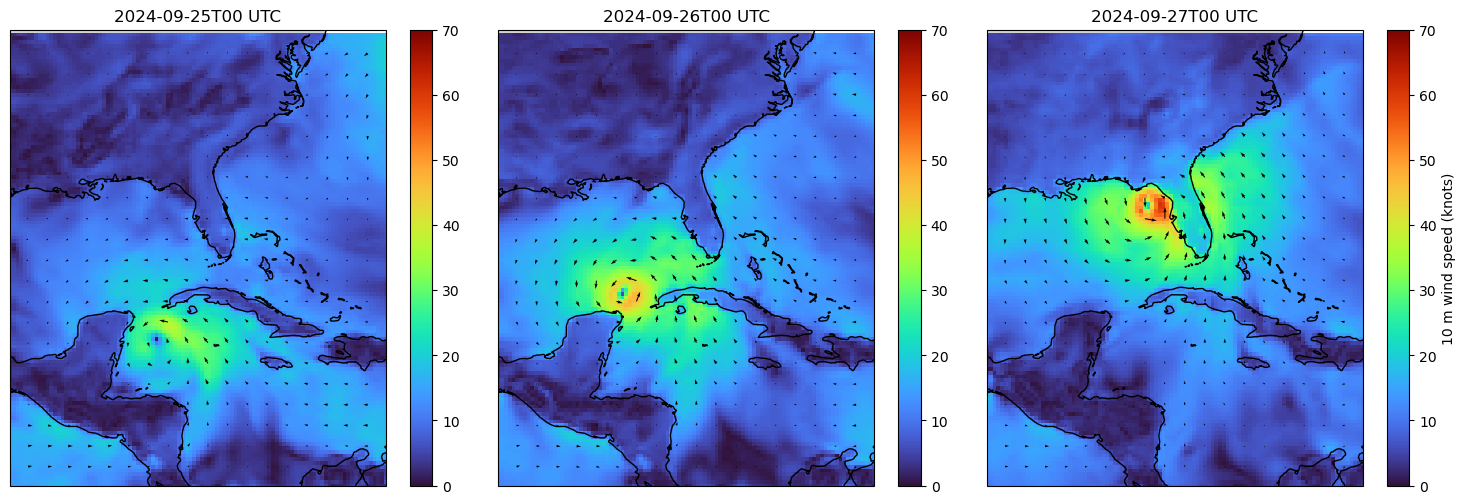

In [5]:
#convert time to a value and set up subplots 
times = ds.time.values
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})

#same looping method employed except indexing times since we have a different time each iteration 
for ax, t in zip(axes, times):
    ws_t = ws.sel(time=t) #for winds
    u_t, v_t = u.sel(time=t), v.sel(time=t) #and components

    ws_t.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="turbo", vmin=0, vmax=70, cbar_kwargs={'label': '10 m wind speed (knots)'} 
              if ax==axes[-1] #build in if else statement for indexing 
              else {})
    #plot wind barbs 1/6 of them to reduce density 
    ax.quiver(ws_t.longitude[::6], ws_t.latitude[::6], u_t[::6, ::6], v_t[::6, ::6], transform=ccrs.PlateCarree(), scale=700, regrid_shape=20)

    #map features 
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.set_extent([-95, -70, 10, 40])
    ax.set_title(str(np.datetime_as_string(t, unit='h')) + " UTC")

plt.tight_layout()
plt.show()

### ChatGPT helped me with the below cell, and I commented throughout to understand the process better 

## Second Subsection: NHC Wind Contours 

✅ Loaded 25 best-track points for Hurricane Helene (2024)


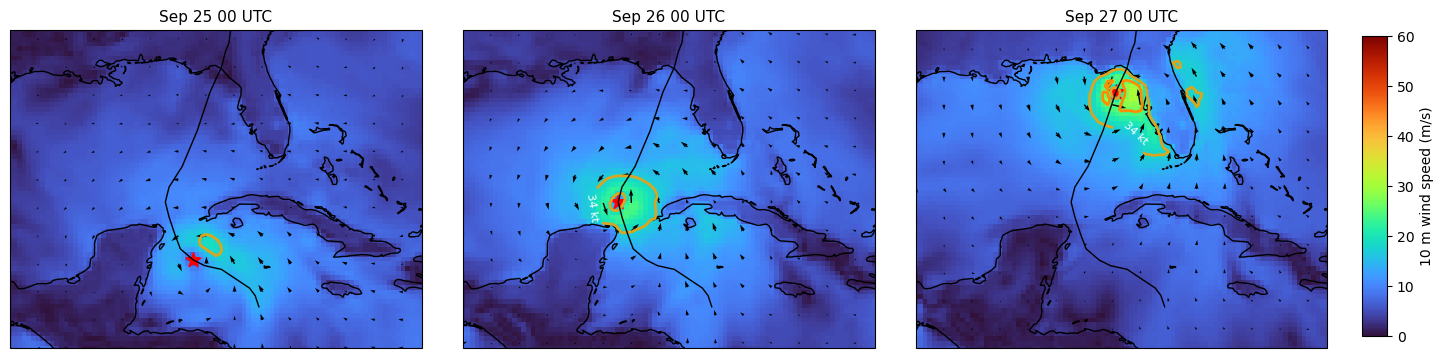

In [6]:
#Helene best track from HURDAT which is a lower res plotting of its track (1851-2024)
url = "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2024-040425.txt"
#open from the web and decode each line to the UTF-8 that it's compatible with - ChatGPT
with urllib.request.urlopen(url) as f: 
    lines = [line.decode("utf-8").strip() for line in f.readlines()]

#what lines are associated with Helene? Filter
storm_lines = []
capture = False
for l in lines:
    #this is the header number for Helene
    if l.startswith("AL092024"):
        capture = True
        storm_lines.append(l)
        continue
    #if Helene's header stops, stop the filtering process
    if capture:
        if l.startswith("AL") and not l.startswith("AL092024"):
            break
        storm_lines.append(l)

records = []
for l in storm_lines[1:]: #skip first line 
    parts = [p.strip() for p in l.split(",")] #split each line from commas and strip spaces
    date = pd.to_datetime(parts[0] + parts[1], format="%Y%m%d%H%M") #create datetime object
    #make lat lon numeric 
    lat = float(parts[4][:-1]) * (1 if parts[4][-1] == "N" else -1)
    lon = float(parts[5][:-1]) * (-1 if parts[5][-1] == "W" else 1)
    wind = int(parts[6]) #max winds extract 
    records.append((date, lat, lon, wind)) #append to tuple for plotting 

    
helene = pd.DataFrame(records, columns=["time", "lat", "lon", "wind"])
print(f"✅ Loaded {len(helene)} best-track points for Hurricane Helene (2024)")

#load in winds from dataset opened above with valid time
ds = xr.open_dataset("era5_helene_2024.nc")
if "valid_time" in ds.coords:
    ds = ds.rename({"valid_time": "time"})

u, v = ds["u10"], ds["v10"]

#multiple panels set up with correct time stamps
dates_to_plot = [
    pd.Timestamp("2024-09-25T00:00:00"),
    pd.Timestamp("2024-09-26T00:00:00"),
    pd.Timestamp("2024-09-27T00:00:00"),
]

levels = [34, 50, 64]  #contour NHC thresholds in knots
colors = ["goldenrod", "darkorange", "firebrick"]

fig, axes = plt.subplots(1, 3, figsize=(17, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})

for i, (ax, target_dt) in enumerate(zip(axes, dates_to_plot)):
    #find nearest point to Helene's center
    helene["dt_diff"] = (helene["time"] - target_dt).abs()
    row = helene.loc[helene["dt_diff"].idxmin()]
    storm_time = np.datetime64(row["time"])
    storm_lat, storm_lon = row["lat"], row["lon"]

    #lat lon dynamic plotter set extent far enough out so there's no missing reanalysis 
    lat_min, lat_max = sorted([storm_lat - 15, storm_lat + 15])
    lon_min, lon_max = sorted([storm_lon - 15, storm_lon + 15])

    ds_sub = ds.sel(
        time=storm_time,
        latitude=slice(lat_max, lat_min),  #ERA5 expects descending order
        longitude=slice(lon_min, lon_max)
    )
    u_sub, v_sub = ds_sub["u10"], ds_sub["v10"]
    ws_sub = np.sqrt(u_sub**2 + v_sub**2)
    ws_knots = ws_sub * 1.94384  #kts

    #smooth shading 
    im = ax.pcolormesh(ws_sub.longitude, ws_sub.latitude, ws_sub,
                       cmap="turbo", shading="auto",
                       vmin=0, vmax=60, transform=ccrs.PlateCarree())

    #contours
    cs = ax.contour(ws_knots.longitude, ws_knots.latitude, ws_knots,
                    levels=levels, colors=colors, linewidths=2,
                    transform=ccrs.PlateCarree())
    ax.clabel(cs, fmt="%d kt", inline=True, fontsize=8, colors="white")

    #windbarbs plot 1/6 lower density 
    ax.quiver(ws_sub.longitude[::6], ws_sub.latitude[::6],
              u_sub[::6, ::6], v_sub[::6, ::6],
              transform=ccrs.PlateCarree(), scale=700)

    #mapping features 
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"))
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.plot(helene["lon"], helene["lat"], color="black", lw=1.0,
            transform=ccrs.PlateCarree())
    ax.scatter(storm_lon, storm_lat, color="red", marker="*", s=120,
               transform=ccrs.PlateCarree())

    #keep axis extent the same though don't have it move 
    ax.set_extent([-95, -73, 15, 32])
    ax.set_title(f"{target_dt:%b %d 00 UTC}", fontsize=11)

#colorbar 
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
fig.colorbar(im, cax=cbar_ax, label="10 m wind speed (m/s)")

plt.subplots_adjust(wspace=0.1)
plt.show()

### Helene's Tropical Storm Force Winds diameter is larger than the Yucatan Channel by a significant amount. I wanted to plot the NHC wind radii, but there was a placeholder file and the data has not been released to my knowledge yet. However, it is apparent that there's a lot of inertia in the ocean from the large wind radii, and when pushed onto Florida's flat and concave coastline, the water funnels in and can result in storm surge upwards of 20ft in extreme cases. This effect can also be enhanced by the coastal bathymetry or the depth of the ocean floor. There is a shallow and large expanse of continental shelp on the West Coast of Florida that allows the ocean to pile up easier than a continental shelf that drops straight off like on the East Coast of Floria. The West Coast has a much higher storm surge risk due to the concave coastline and the coastal bathymetry. Let's plot it to visualize this idea better. 

## Second Section: Bathymetry 

In [7]:
#load GeoTIFF gotten from NOAA/NCEI
bathy = rioxarray.open_rasterio("exportImage.tiff")
bathy

<xarray.DataArray (band: 1, y: 2160, x: 2640)> Size: 23MB
[5702400 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 21kB -95.0 -94.99 -94.98 ... -73.02 -73.01 -73.0
  * y            (y) float64 17kB 33.0 32.99 32.98 32.97 ... 15.02 15.01 15.0
    spatial_ref  int64 8B 0
Attributes:
    DataType:         Generic
    AREA_OR_POINT:    Area
    SourceBandIndex:  0
    scale_factor:     1.0
    add_offset:       0.0

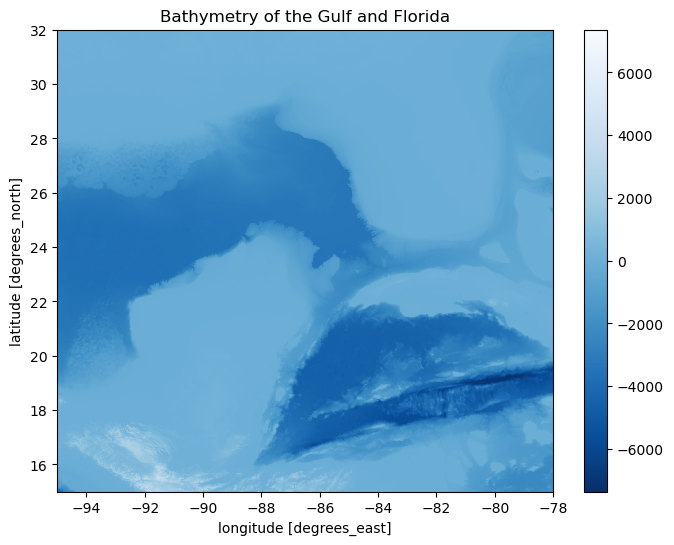

In [8]:
#subset region for the Gulf + Florida
bathy_sub = bathy.rio.clip_box(minx=-98, miny=15, maxx=-78, maxy=32)

#visualize subset 
bathy_sub.plot(figsize=(8,6), cmap="Blues_r")
plt.title("Bathymetry of the Gulf and Florida")
plt.show()

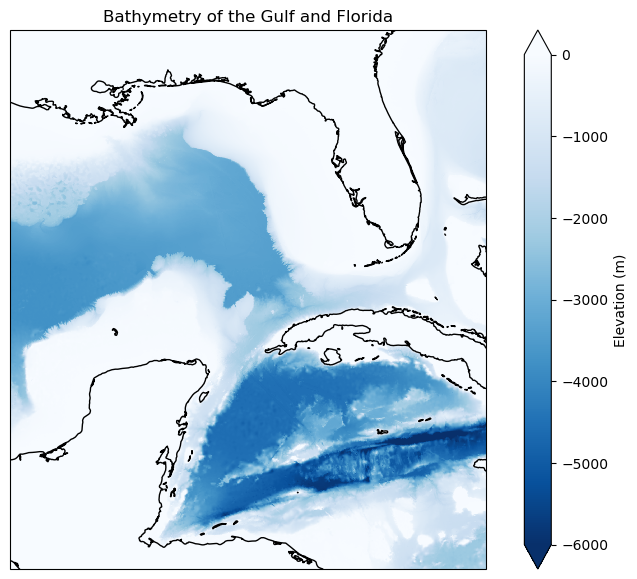

In [9]:
fig, ax = plt.subplots(figsize=(10,7), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-93, -78, 15, 32])

#plot coastline better visualization 
ax.add_feature(cfeature.COASTLINE.with_scale("10m"))
ax.add_feature(cfeature.LAND, facecolor="lightgray")

#use xarray plotfor coords 
bathy_sub.squeeze().plot(ax=ax, transform=ccrs.PlateCarree(), cmap="Blues_r", vmin=-6000, vmax=0, cbar_kwargs={"label": "Elevation (m)"})

ax.set_title("Bathymetry of the Gulf and Florida")
plt.show()

### Notice the expansive shallow coastline to the West of Florida which allows water to build up easier as a hurricane approaches, especially one as large as Helene. Let's look at the tide gauge data along the West Coast of Florida to track the surge.

## Third Section: Storm Surge Data Through Tide Gauges

In [10]:
url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=water_level&application=web_services&begin_date=20240925&end_date=20240930&datum=MSL&station=8727520&time_zone=GMT&units=metric&format=csv"
df = pd.read_csv(url)
print(df.columns)
df.head()

Index(['Date Time', ' Water Level', ' Sigma', ' O or I (for verified)', ' F',
       ' R', ' L', ' Quality '],
      dtype='object')


,Date Time,Water Level,Sigma,O or I (for verified),F,R,L,Quality
0,2024-09-25 00:00,0.469,0.003,0,0,0,0,v
1,2024-09-25 00:06,0.487,0.002,0,0,0,0,v
2,2024-09-25 00:12,0.491,0.002,0,0,0,0,v
3,2024-09-25 00:18,0.490,0.002,0,0,0,0,v
4,2024-09-25 00:24,0.486,0.002,0,0,0,0,v


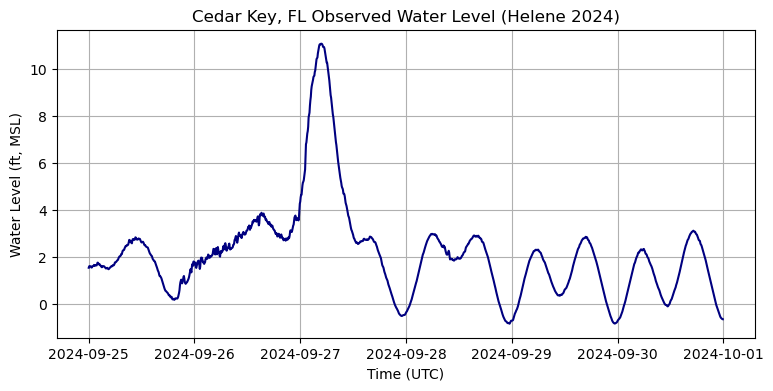

In [11]:
#NOAA COOPS water level data for Cedar Key, FL
url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=water_level&application=web_services&begin_date=20240925&end_date=20240930&datum=MSL&station=8727520&time_zone=GMT&units=metric&format=csv"

#read and remove leading and trailing spaces 
df = pd.read_csv(url)
df.columns = df.columns.str.strip() 

#time to datetime
df["Date Time"] = pd.to_datetime(df["Date Time"])

#meters to feet
df["Water Level (ft)"] = df["Water Level"] * 3.28084

#plotting 
plt.figure(figsize=(9, 4))
plt.plot(df["Date Time"], df["Water Level (ft)"], color="navy")
plt.title("Cedar Key, FL Observed Water Level (Helene 2024)")
plt.ylabel("Water Level (ft, MSL)")
plt.xlabel("Time (UTC)")
plt.grid(True)
plt.show()

### Close to 12 feet of storm surge observed at Cedar Key's tide gauge! That's two tall people stacked together, and the peak occured just as Helene was moving up the Florida Coast and just as the eye passed Cedar Key. The cyclonic flow must've enhanced the water funneling into the island. 

### How abnormal is this rise in the ocean? Here's the corresponding predicted tide cycle for Cedar Key in orange for some context.

## Subsection: Predicted Tides vs Observed Tide Gauge Values

In [12]:
# Make sure you're not reusing a hurricane URL
url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?product=water_level&application=web_services&begin_date=20240925&end_date=20240930&datum=MSL&station=8727520&time_zone=GMT&units=metric&format=csv"
url_pred = url.replace("product=water_level", "product=predictions")

# Now reload both fresh
obs = pd.read_csv(url)
pred = pd.read_csv(url_pred)

print(obs.columns)
print(pred.columns)

Index(['Date Time', ' Water Level', ' Sigma', ' O or I (for verified)', ' F',
       ' R', ' L', ' Quality '],
      dtype='object')
Index(['Date Time', ' Prediction'], dtype='object')


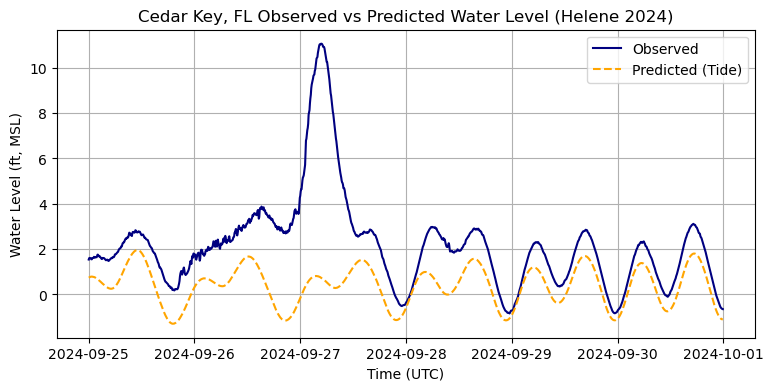

In [13]:
#observed and predicted water levels read in
obs = pd.read_csv(url)
pred = pd.read_csv(url_pred)

#clean up whitespace and convert to datetime
for df_ in [obs, pred]:
    df_.columns = df_.columns.str.strip()
    df_["Date Time"] = pd.to_datetime(df_["Date Time"])

#rename
obs = obs.rename(columns={"Water Level": "Water Level (m)"})
pred = pred.rename(columns={"Prediction": "Water Level (m)"})

#merge with matchind datetime
merged = pd.merge(obs, pred, on="Date Time", suffixes=("_obs", "_pred"))

#meters to feet
m_to_ft = 3.28084
merged["Water Level (ft)_obs"] = merged["Water Level (m)_obs"] * m_to_ft
merged["Water Level (ft)_pred"] = merged["Water Level (m)_pred"] * m_to_ft
merged["Surge (ft)"] = (merged["Water Level (m)_obs"] - merged["Water Level (m)_pred"]) * m_to_ft

#plot observed vs predicted 
plt.figure(figsize=(9,4))
plt.plot(merged["Date Time"], merged["Water Level (ft)_obs"], color="navy", label="Observed")
plt.plot(merged["Date Time"], merged["Water Level (ft)_pred"], color="orange", linestyle="--", label="Predicted (Tide)")
plt.title("Cedar Key, FL Observed vs Predicted Water Level (Helene 2024)")
plt.ylabel("Water Level (ft, MSL)")
plt.xlabel("Time (UTC)")
plt.legend()
plt.grid(True)
plt.show()

## What about other locations along the West Coast of Floirda? Let's check Tampa Bay, Clearwater, and Apalachicola and compare their storm surge recorded by tide gauges to Cedar Key

### ChatGPT helped me with this cell regarding defining a function that goes through four tide gauge IDs and constructs the urls 

In [14]:
def fetch_surge(station_id, start="20240925", end="20240930"):
    """
    Download observed and predicted water levels from NOAA CO-OPS,
    compute the storm surge residual (observed - predicted),
    and return a DataFrame of time series data for a given station.
    """
    #API NOAA Tides and Currents 
    base_url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
    
    # Common query parameters for both observed and predicted data:
    # - MSL datum (mean sea level)
    # - GMT timezone
    # - metric units
    # - CSV output
    # - Start and end dates provided as arguments
    common = (
        f"&application=web_services&begin_date={start}&end_date={end}"
        f"&datum=MSL&time_zone=GMT&units=metric&format=csv"
    )
    
    # Construct full URLs for both products:
    # 'water_level' = observed gauge readings
    # 'predictions' = astronomical tide forecast (no meteorological effect)
    url_obs = f"{base_url}?product=water_level&station={station_id}{common}"
    url_pred = f"{base_url}?product=predictions&station={station_id}{common}"
    
    #read CSVs 
    obs = pd.read_csv(url_obs)
    pred = pd.read_csv(url_pred)
    
    #remove leading and trailing spaces 
    obs.columns = obs.columns.str.strip()
    pred.columns = pred.columns.str.strip()
    
    #datetime objects for merging and plotting
    obs["Date Time"] = pd.to_datetime(obs["Date Time"])
    pred["Date Time"] = pd.to_datetime(pred["Date Time"])
    
    #merge with corresponding date times 
    merged = pd.merge(
        obs[["Date Time", "Water Level"]],
        pred[["Date Time", "Prediction"]],
        on="Date Time",
        how="inner"
    )
    
    # how much higher the observed water level is compared to the tide prediction? - residual 
    merged["Surge (m)"] = merged["Water Level"] - merged["Prediction"]
    
    #meters to ft
    merged["Surge (ft)"] = merged["Surge (m)"] * 3.28084

    
    # Return a tidy DataFrame for this station
    return merged

#8727520 Cedar Key
#8728690 Apalachicola
#8726724 Clearwater Beach
#8726607 Tampa
stations = {
    "Cedar Key": "8727520",
    "Apalachicola": "8728690",
    "Clearwater": "8726724",
    "Tampa": "8726607"
}

✅ Retrieved surge data for Cedar Key
✅ Retrieved surge data for Apalachicola
✅ Retrieved surge data for Clearwater
✅ Retrieved surge data for Tampa


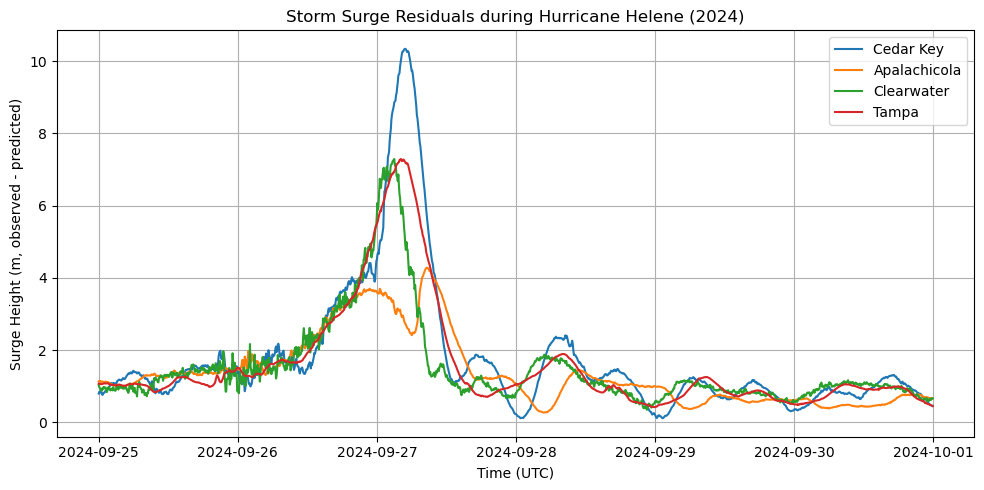

In [15]:
#load in surge data 
dfs = []
for name, sid in stations.items():
    try:
        #function call for each station 
        df = fetch_surge(sid)
        #add station column
        df["station_name"] = name
        dfs.append(df)
        print(f"✅ Retrieved surge data for {name}")
    except Exception as e:
        print(f"⚠️  Could not load {name}: {e}")

#combine concat 
all_surge = pd.concat(dfs, ignore_index=True)

#plotting with a loop
plt.figure(figsize=(10, 5))

for name in stations.keys():
    #new subset each time for station data 
    subset = all_surge[all_surge["station_name"] == name]
    #plot over specific datetime
    plt.plot(subset["Date Time"], subset["Surge (ft)"], label=name)

#labels 
plt.title("Storm Surge Residuals during Hurricane Helene (2024)")
plt.ylabel("Surge Height (m, observed - predicted)")
plt.xlabel("Time (UTC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Very fascinating to compare the four stations and their peak surge values! Apalachicola, which was by far the closest to Helene's eye, had the least storm surge. It was on the right side of the storm to the west of the eye, and the cyclonic winds, for the majority of Helene's passage, pushed the ocean out and away from the tide gauge instead of towards it. All three of the other stations are to the east of the eye, on the "dirty" side of the hurricane, and have noticibly larger values in peak storm surge. 

### How atypical are the values for each of these stations? Let's compare it to the predicted tide cycles for these specific times. 

✅ Retrieved surge data for Cedar Key
✅ Retrieved surge data for Apalachicola
✅ Retrieved surge data for Clearwater
✅ Retrieved surge data for Tampa


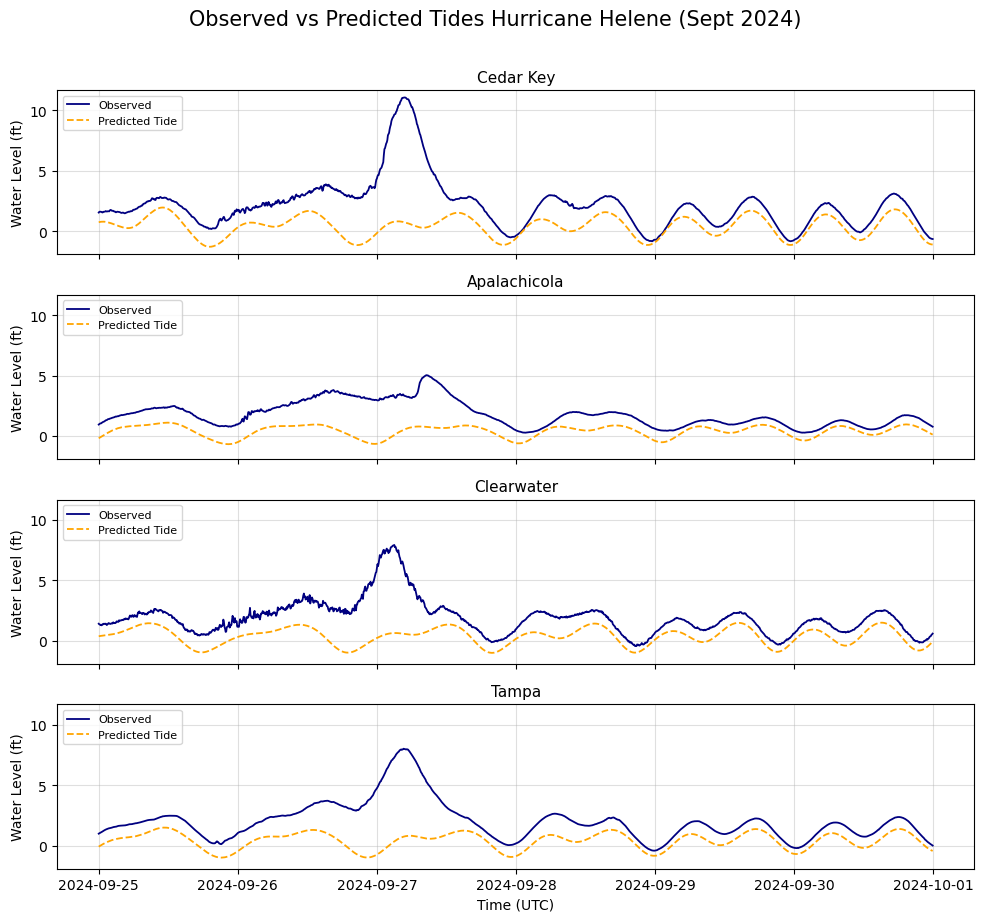

In [16]:
#get surge dat for each station 
data = {}
for name, sid in stations.items():
    try:
        # Fetch surge data for each NOAA tide station
        df = fetch_surge(sid)
        # Store the resulting DataFrame under the station name
        data[name] = df
        print(f"✅ Retrieved surge data for {name}")
    except Exception as e:
        # Handle missing data or connection errors gracefully
        print(f"⚠️ Could not load {name}: {e}")

#plotting 
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True, sharey=True)

for ax, (name, df) in zip(axes, data.items()):
    #convert to feet 
    df["Water Level (ft)"] = df["Water Level"] * 3.28084
    df["Prediction (ft)"] = df["Prediction"] * 3.28084
    
    #observed water level in blue
    ax.plot(df["Date Time"], df["Water Level (ft)"], color="navy", lw=1.3, label="Observed")

    #predicted astronomical tide in orange (dashed)
    ax.plot(df["Date Time"], df["Prediction (ft)"], color="orange", lw=1.3, linestyle="--", label="Predicted Tide")

    #labels
    ax.set_ylabel("Water Level (ft)")
    ax.set_title(f"{name}", fontsize=11)

    #grid and legend
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8, loc="upper left")

#labels shared 
axes[-1].set_xlabel("Time (UTC)")

#title 
fig.suptitle("Observed vs Predicted Tides Hurricane Helene (Sept 2024)", fontsize=15, y=1.02)
plt.tight_layout()
fig.subplots_adjust(top=0.93)
plt.show()

### For some more context, let's plot the station locations on the bathymetry map alongside Helene's path. 

## Fourth Section: Plotting Cities on Bathymetry Map

In [17]:
#IBTrACS full dataset csv
url = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv"

#choose columns to load
cols = ["SID", "SEASON", "NAME", "ISO_TIME", "LAT", "LON", "USA_WIND", "USA_PRES", "BASIN"]
ib = pd.read_csv(url, usecols=cols)

#filter for Helene
helene = ib[(ib["NAME"] == "HELENE") & (ib["SEASON"] == 2024)].copy()
helene = helene.dropna(subset=["LAT", "LON"])

#coordinates to numerical values
helene["LAT"] = pd.to_numeric(helene["LAT"], errors="coerce")
helene["LON"] = pd.to_numeric(helene["LON"], errors="coerce")

#time to datetime 
helene["ISO_TIME"] = pd.to_datetime(helene["ISO_TIME"], errors="coerce")

print(f"Loaded {len(helene)} Helene points from IBTrACS")
helene.head()

Loaded 0 Helene points from IBTrACS


/tmp/ipykernel_4044727/361863720.py:6: DtypeWarning: Columns (1,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  ib = pd.read_csv(url, usecols=cols)


,SID,SEASON,BASIN,NAME,ISO_TIME,LAT,LON,USA_WIND,USA_PRES


### ChatGPT helped me with plotting the stations on the bathymetry map with their approximate peak storm surge values. It helped me define a dunction that get's the maximum storm surge values with the corresponding valid time, which can then be used for a lat lon plot later on with the map. 

In [18]:
bath_path = "exportImage.tiff"
bath = rasterio.open(bath_path)  #open raster dataset with rasterio

#define metadata for each station 
stations = {
    "Cedar Key": {"id": "8727520", "lat": 29.135, "lon": -83.035},
    "Apalachicola": {"id": "8728690", "lat": 29.727, "lon": -84.983},
    "Clearwater": {"id": "8726724", "lat": 27.978, "lon": -82.832},
    "Tampa": {"id": "8726607", "lat": 27.933, "lon": -82.449}
}


In [19]:
# Function to fetch and compute *peak* storm surge per station
def fetch_peak_surge(station_id, start="20240925", end="20240930"):
    """
    Fetch NOAA CO-OPS observed and predicted water levels for a given station,
    compute the storm surge residual (observed - predicted),
    and return the *maximum* surge value and its timestamp.
    """
    base_url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
    # Shared API parameters for both products
    common = (
        f"&application=web_services&begin_date={start}&end_date={end}"
        f"&datum=MSL&time_zone=GMT&units=metric&format=csv"
    )
    
    # NOAA CO-OPS endpoints:
    url_obs = f"{base_url}?product=water_level&station={station_id}{common}"  # observed tide gauge data
    url_pred = f"{base_url}?product=predictions&station={station_id}{common}"  # astronomical tide prediction
    
    #read data from constructed urls 
    obs = pd.read_csv(url_obs)
    pred = pd.read_csv(url_pred)
    
    #whitespace 
    obs.columns = obs.columns.str.strip()
    pred.columns = pred.columns.str.strip()
    
    #datetime object
    obs["Date Time"] = pd.to_datetime(obs["Date Time"])
    pred["Date Time"] = pd.to_datetime(pred["Date Time"])
    
    #merge observed and predicted values with corresponding datetime
    merged = pd.merge(
        obs[["Date Time", "Water Level"]],
        pred[["Date Time", "Prediction"]],
        on="Date Time",
        how="inner"
    )
    
    #surge residual (observed - predicted)
    merged["Surge (m)"] = merged["Water Level"] - merged["Prediction"]
    
    # Find the maximum surge height
    peak = merged.loc[merged["Surge (m)"].idxmax()]
    
    #return peak surge in meters and the time it occurred
    return peak["Surge (m)"], peak["Date Time"]

## Here is the final map for context of where the tide gauge locations are. 

✅ Cedar Key: 3.15 m (10.34 ft) at 2024-09-27 04:54:00
✅ Apalachicola: 1.30 m (4.28 ft) at 2024-09-27 08:36:00
✅ Clearwater: 2.22 m (7.29 ft) at 2024-09-27 03:00:00
✅ Tampa: 2.22 m (7.29 ft) at 2024-09-27 04:06:00


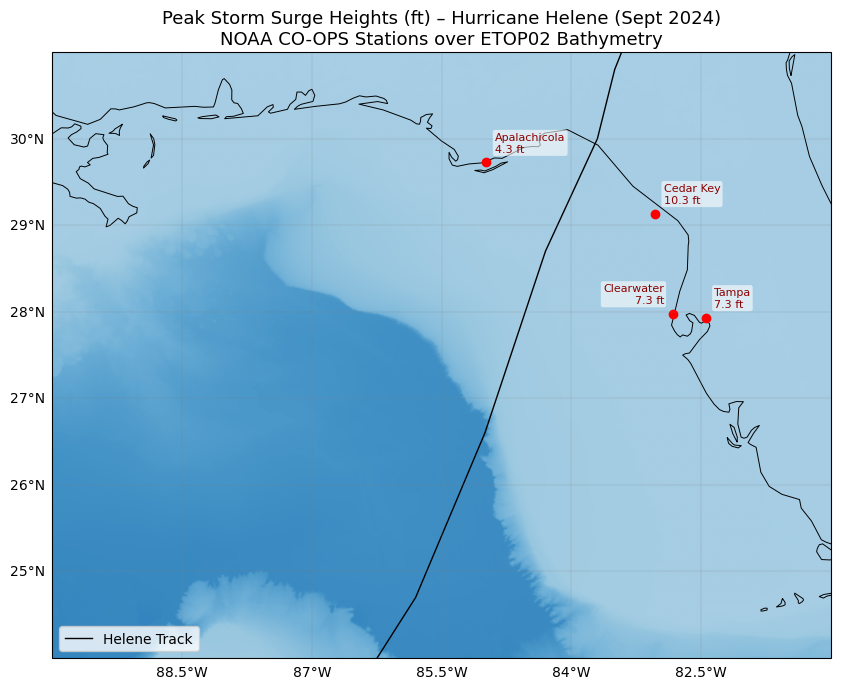

In [20]:
for name, s in stations.items():
    try:
        surge_max_m, tmax = fetch_peak_surge(s["id"])
        
        #meters to feet
        surge_max_ft = surge_max_m * 3.28084
        
        #store values back into the station dictionary
        stations[name]["max_surge_m"] = round(float(surge_max_m), 2)
        stations[name]["max_surge_ft"] = round(float(surge_max_ft), 2)
        stations[name]["tmax"] = tmax
        
        #print info check
        print(f"✅ {name}: {surge_max_m:.2f} m ({surge_max_ft:.2f} ft) at {tmax}")
    except Exception as e:
        #if data call fails, create a placeholder
        print(f"⚠️ Could not retrieve {name}: {e}")
        stations[name]["max_surge_m"] = None
        stations[name]["max_surge_ft"] = None
        stations[name]["tmax"] = None

# Load Hurricane Helene's best-track data from HURDAT2  1851–2024.
url = "https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2024-040425.txt"
with urllib.request.urlopen(url) as f:
    lines = [line.decode("utf-8").strip() for line in f.readlines()] #read in utf8 

# Parse out only the section belonging to Helene (AL092024)
storm_lines, capture = [], False
for l in lines:
    if l.startswith("AL092024"): #get Helene
        capture = True
        storm_lines.append(l)
        continue
    if capture:
        #stop once the next storm header appears
        if l.startswith("AL") and not l.startswith("AL092024"):
            break
        storm_lines.append(l)

#parse each record into date, lat, lon, and max wind speed
records = []
for l in storm_lines[1:]:  #skip metadata header line
    parts = [p.strip() for p in l.split(",")]
    date = pd.to_datetime(parts[0] + parts[1], format="%Y%m%d%H%M")
    lat = float(parts[4][:-1]) * (1 if parts[4][-1] == "N" else -1)
    lon = float(parts[5][:-1]) * (-1 if parts[5][-1] == "W" else 1)
    wind = int(parts[6])
    records.append((date, lat, lon, wind))

#create DataFrame for Helene's best track
helene = pd.DataFrame(records, columns=["time", "lat", "lon", "wind"])

#plotting
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

#bathymetry 
show(bath, ax=ax, transform=ccrs.PlateCarree(), cmap="Blues_r")

#add coastlines for visual context
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.7)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

ax.set_extent([-90, -81, 24, 31])

#Helene best track
ax.plot(helene["lon"], helene["lat"], color="black", lw=1.0, transform=ccrs.PlateCarree(), label="Helene Track")

#tide gauge locations in red 
for name, s in stations.items():
    if s["max_surge_ft"] is None:
        continue  #skip stations that failed to load

    #plot
    ax.plot(s["lon"], s["lat"], "ro", markersize=6, transform=ccrs.PlateCarree())

    # Default text offset
    dx, dy = 0.1, 0.1
    ha = "left"

    #adjust label placement for Clearwater to avoid overlap with Tampa
    if name == "Clearwater":
        dx = -0.1
        ha = "right"

    #station name and peak surge (ft)
    ax.text(
        s["lon"] + dx, s["lat"] + dy,
        f"{name}\n{round(s['max_surge_ft'],1)} ft",
        fontsize=8, color="darkred",
        ha=ha, va="bottom",
        transform=ccrs.PlateCarree(),
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", boxstyle="round,pad=0.2")
    )

#title and grid
ax.set_title("Peak Storm Surge Heights (ft) – Hurricane Helene (Sept 2024)\nNOAA CO-OPS Stations over ETOP02 Bathymetry", fontsize=13)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

#legend 
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

### Cedar Key had compunding effects of proximity to Helene's eye while being on the right side of the storm, as well as the effect of a concave coastline enhancing the convergence of storm surge. Clearwater and Tampa Bay have similar values of surge, although Clearwater is an example of a convex coastline where it has more diverging waters. This effect is made up by its exposure to storm surge as its coastline is directly on the Gulf. There's an enhancement in convergence and storm surge by the concave coastline bay in Tampa, and even though it is less directly exposed, this effect gives it around the same value for observed surge as Clearwater. Once again, as mentioned above, Apalachicola was the closest to Helene's eye, but with it being on the west side of the storm with most of the storm's circulation blowing offshore, the effects of the storm surge were much less than the West Coast of Florida. 

---

## Summary

### The storm surge impacts of Helene on Florida highlight the compound nature of coastal hazard risk. Although Helene may not have had the highest wind speeds, its broad wind field and relatively slow land-interaction phase allowed for sustained onshore pressure gradients that elevated surge levels along vulnerable stretches of coastline. Coupled with elevated bathymetry and the presence of shallow continental shelf zones along parts of Florida’s coast, the surge effects were amplified. The observational water-level time-series from the NOAA Center for Operational Oceanographic Products and Services (CO-OPS) dataset reveal residual surge values that exceeded model forecasts, reinforcing that local bathymetric and meteorological factors can meaningfully modulate surge during storms of moderate intensity.

:::{note}
There is definitely a more efficient way to do this last part... And I am still in the process of gathering more storm surge datasets to finish this notebook 
:::

---

### What's Next?

Potential next steps include:

- Incorporate tide gauge or river gauge observations to validate modeled surge heights  
- Couple atmospheric and hydrologic datasets to analyze compound flood risk (CoCoRaHS?)
- Look at damage estimate datasets based on region 

---

## Resources and References

**Datasets**
- [ERA5 Reanalysis (C3S, 2023)](https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5) — wind and pressure fields used for surge context  
- [USGS Water Data](https://waterdata.usgs.gov/) — river gauge and discharge observations  
- [NOAA Tides & Currents](https://tidesandcurrents.noaa.gov/) — coastal tide gauge records  

**Software & Tools**
- [Geopandas](https://geopandas.org/) for shapefile and spatial analysis  
- [rioxarray](https://corteva.github.io/rioxarray/stable/) and [Rasterio](https://rasterio.readthedocs.io/) for topography and surge visualization  
- [Matplotlib](https://matplotlib.org/) for custom surge and flood mapping  

**Further Reading**
- Irish, J. L., Resio, D. T., & Ratcliff, J. J. (2008). *The influence of storm size on hurricane surge.* *Journal of Physical Oceanography 2003–2013.  
- Needham, H. F., Keim, B. D., & Sathiaraj, D. (2015). *A review of tropical cyclone-generated storm surges: Global data sources, observations, and impacts.* *Reviews of Geophysics  
